<a href="https://colab.research.google.com/github/mukulhayaran/pyTorch-Learning/blob/main/pyTorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_blobs
from sklearn.manifold import TSNE
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import time
import matplotlib.pyplot as plt

In [ ]:
data = [1.0, 2.0, 3.0]
tensor= torch.Tensor(data)
tensor
multidim_data=[data, data]
torch.Tensor(multidim_data)

tensor([[1., 2., 3.],
        [1., 2., 3.]])

Random Tensors:

In [ ]:
rand=torch.randn(2,3,3)
rand

tensor([[[ 0.3786, -0.6190,  2.7733],
         [-0.0146, -0.0689,  1.5674],
         [-1.3109, -0.0881,  1.2375]],

        [[-0.1028,  0.4522,  0.2122],
         [-0.2106,  1.7819, -0.5392],
         [ 0.2348, -0.4907,  0.6881]]])

Derivative: 3*(x+2)^2

In [ ]:
x= torch.ones(1, requires_grad=True)
y= x+2
z= y**2 *3
z.backward()
x.grad
y.grad

/tmp/ipykernel_560/3596251037.py:6: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more information. (Triggered internally at /pytorch/build/aten/src/ATen/core/TensorBody.h:492.)
  y.grad


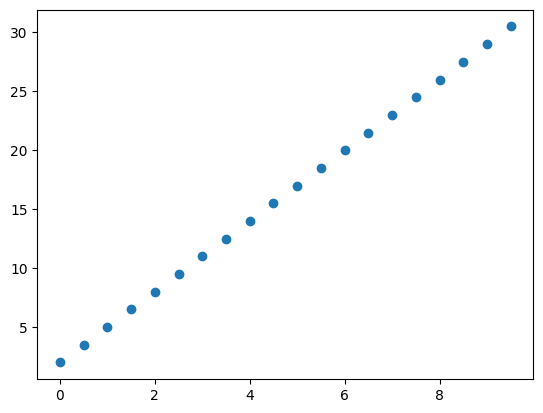

In [ ]:
x=np.arange(0,10,0.5)
y= 2+ 3*x
plt.scatter(x,y)
plt.show()

In [ ]:
x,y = x.reshape(-1,1), y.reshape(-1,1)
model=LinearRegression()
model.fit(x,y)
model.coef_, model.intercept_

(array([[3.]]), array([2.]))

Linear Regression + SGD using PyTorch:

In [ ]:
torch.seed()
class SGDRegressor(nn.Module):
  def __init__(self):
    super().__init__()
    self.fc1=nn.Linear(1,1) ## Linear layer , (inputs, outputs)

  def forward(self,x):  ## logic for passing data in the model?
    y=self.fc1(x)
    return y

model=SGDRegressor()
loss_fn=torch.nn.MSELoss()
optimizer= torch.optim.SGD(model.parameters(), lr=0.01)
EPOCHS= 5000

X_train= torch.tensor(x , dtype=torch.float32)
y_train=torch.tensor(y , dtype=torch.float32)


In [ ]:
for name, param in model.named_parameters():
  print(name,param)

fc1.weight Parameter containing:
tensor([[-0.1429]], requires_grad=True)
fc1.bias Parameter containing:
tensor([-0.7565], requires_grad=True)


In [ ]:
for epoch in range(EPOCHS):
  y_pred = model(X_train)
  loss= loss_fn(y_pred, y_train)
  loss.backward() #calculate gradient
  optimizer.step()
  optimizer.zero_grad() #reset gradients

In [ ]:
for name, param in model.named_parameters():
  print(name,param)

fc1.weight Parameter containing:
tensor([[3.0000]], requires_grad=True)
fc1.bias Parameter containing:
tensor([2.0000], requires_grad=True)


CLASSIFICATION & LOGISTIC REGRESSION

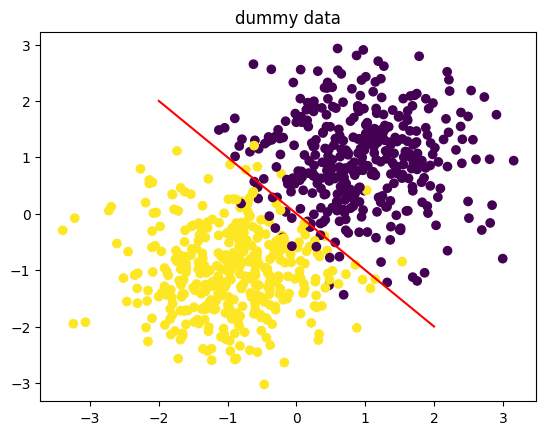

In [ ]:
 #dummy data
 centers= [[1,1],[-1,-1]]

 X,y=make_blobs(n_samples=750,centers=centers, cluster_std=0.8,random_state=0)

 plt.scatter(X[:,0],X[:,1],c=y) #X:(v1,v2): X[:,0] gives v1 for all samples in X
 plt.title("dummy data")
 plt.plot([-2,2],[2,-2],"r") #draws the red line
 plt.show()

 y=y.reshape(-1,1)

In [ ]:
torch.seed()

class LogisticRegression(nn.Module):
  def __init__(self):
    super().__init__()
    self.fc1=nn.Linear(2,1)  #linear input taking 2 inputs and giving 1 o/p, shape of X:(750,2), y:(750,1)

  def forward(self, x):
    z=self.fc1(x)
    y=torch.sigmoid(z)
    return y

model= LogisticRegression()
loss_fn=torch.nn.BCELoss()
optimizer= torch.optim.SGD(model.parameters(), lr=0.01)
EPOCHS= 5000

X_train=torch.tensor(X,dtype=torch.float32)
y_train=torch.tensor(y,dtype=torch.float32)
model(X_train)

tensor([[0.4600],
        [0.4094],
        [0.3974],
        [0.2410],
        [0.5161],
        [0.4202],
        [0.2794],
        [0.3331],
        [0.3839],
        [0.4496],
        [0.4466],
        [0.2454],
        [0.4220],
        [0.2986],
        [0.3612],
        [0.4807],
        [0.2765],
        [0.3187],
        [0.3276],
        [0.2424],
        [0.2530],
        [0.2933],
        [0.3099],
        [0.2612],
        [0.2814],
        [0.3471],
        [0.2560],
        [0.4969],
        [0.4754],
        [0.3376],
        [0.4222],
        [0.4605],
        [0.3353],
        [0.4422],
        [0.4425],
        [0.3851],
        [0.3171],
        [0.5099],
        [0.4286],
        [0.3589],
        [0.3425],
        [0.2954],
        [0.4258],
        [0.2388],
        [0.4310],
        [0.3180],
        [0.3986],
        [0.3458],
        [0.5508],
        [0.3037],
        [0.3401],
        [0.3142],
        [0.3871],
        [0.4476],
        [0.3070],
        [0

In [ ]:
for epoch in range(EPOCHS):
  y_pred=model(X_train)
  loss=loss_fn(y_pred,y_train)
  loss.backward()
  optimizer.step()
  optimizer.zero_grad()



In [ ]:
with torch.inference_mode(): #does not compute the gradients
  y_final_pred=model(X_train)

torch.mean(((y_final_pred>0.5).int() == y_train).float())

tensor(0.9680)

MNIST Deep learning model


In [ ]:
import torchvision
import torchvision.transforms as transforms

In [ ]:
train = torchvision.datasets.MNIST('./data', train=True, download=True,
    transform=transforms.Compose([  # CONVERT ARRAY TO TENSOR
        transforms.ToTensor()
    ])
)

test = torchvision.datasets.MNIST('./data', train=False, download=True,
    transform=transforms.Compose([
        transforms.ToTensor()
    ])
)

"""
counter =0
for image, label in train:
  image=image.squeeze()
  plt.imshow(image,cmap="gray")
  plt.title(label)
  plt.show()
  counter+=1
  if counter==10:
    break
"""

'\ncounter =0\nfor image, label in train:\n  image=image.squeeze()\n  plt.imshow(image,cmap="gray")\n  plt.title(label)\n  plt.show()\n  counter+=1\n  if counter==10:\n    break\n'

In [ ]:
BATCH_SIZE=128
LOSS=nn.CrossEntropyLoss()
LR=0.008
EPOCHS=5

In [ ]:
#DATALOADER:

trainset= torch.utils.data.DataLoader(train,batch_size=BATCH_SIZE, shuffle=True)
test= torch.utils.data.DataLoader(test,batch_size=BATCH_SIZE, shuffle=True)

for images,labels in trainset:
  print(images.shape)
  print(labels.shape)
  break


torch.Size([128, 1, 28, 28])
torch.Size([128])


In [ ]:
class FCNet(nn.Module):
  def __init__(self):
    super().__init__()
    self.fc1 = nn.Linear(28*28,64)
    self.fc2=nn.Linear(64,10)

  def forward(self,x):
    batch_size=x.shape[0]
    x=x.reshape(batch_size,-1)
    x=F.relu(self.fc1(x))
    logits=self.fc2(x)

    return logits


In [ ]:
model=FCNet()
optimizer=optim.Adam(model.parameters(), lr=LR)
for epoch in range(EPOCHS):
  print(f"training epoch {epoch+1}")

  losses=[]

  for images,labels in trainset:

    forward_out=model(images)
    loss=LOSS(forward_out,labels)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    losses.append(loss.item())
  print(f"loss:{np.mean(losses)}")



training epoch 1
loss:0.26229810888674465
training epoch 2
loss:0.12315020072402985
training epoch 3
loss:0.09398155063708453
training epoch 4
loss:0.07787082950944013
training epoch 5
loss:0.0718936323642985


In [ ]:
correct=0
total=0

model.eval()

with torch.inference_mode():
  for images,labels in test:
    forward_out=model(images)
    for idx, i in enumerate(forward_out):
      prediction = torch.argmax(i)
      if prediction == labels[idx]:
        correct+=1
      total+=1
print("accuracy:", round(correct/total,2))

accuracy: 0.97


USING GPU:

In [ ]:
DEVICE="cuda"
#!nvidia -smi

model=FCNet().to(DEVICE) #moved to GPU
optimizer=optim.Adam(model.parameters(), lr=LR)

ADDING VALIDATION LOOP:

In [ ]:
model=FCNet().to(DEVICE)
optimizer=optim.Adam(model.parameters(), lr=LR)
EPOCHS=20
training_avg_losses=[]
validation_avg_losses=[]

for epoch in range(EPOCHS):
  print("Epoch {}".format(epoch+1))
  training_losses=[]
  validation_losses=[]

  model.train()

  for data in trainset:
    X,y=data
    X,y=X.to(DEVICE), y.to(DEVICE)

    optimizer.zero_grad()
    forward_out=model(X)
    loss_val=LOSS(forward_out,y)
    training_losses.append(loss_val.item())
    loss_val.backward()
    optimizer.step()

  model.eval()
  for data in testset: #set to eval mode
    with torch.no_grad(): #wrap with no grad-no computational graph built
      X,y=data
      X,y=X.to(DEVICE), y.to(DEVICE)
      forward_out=model(X)
      loss_val=LOSS(forward_out,y)

      validation_losses.append(loss_val.item())

  training_avg_loss=np.mean(training_Losses)
  validation_avg_loss=np.mean(validation_Losses)
  training_avg_losses.append(training_avg_loss)
  validation_avg_losses.append(validation_avg_loss)
  print("Training Loss: ", training_avg_loss)
  print("Validation Loss: ", validation_avg_loss)



